# Feature Extraction
### MediaPipe FaceMesh + EAR + MobileNetV2

### libraries

In [1]:
import os

# --- MUST be set BEFORE importing tensorflow / mediapipe ---
# Pure-python protobuf parser: defensive fallback so the notebook keeps working
# even if a future `pip install` pulls in protobuf >= 4.x (TF 2.10 was built
# against protobuf 3.20.x and otherwise crashes with
# "TypeError: Descriptors cannot be created directly").
os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import mediapipe as mp

# Expose face_mesh once at the top so every later cell can use it
# without re-importing mediapipe.
mp_face_mesh = mp.solutions.face_mesh

print(f"mediapipe   : {mp.__version__}")
print(f"face_mesh   : {mp_face_mesh.__name__}")
print(f"FaceMesh OK : {hasattr(mp_face_mesh, 'FaceMesh')}")

mediapipe   : 0.10.9
face_mesh   : mediapipe.python.solutions.face_mesh
FaceMesh OK : True


In [2]:
import cv2
import json
import joblib
import random
import threading

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tqdm import tqdm
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Allow incremental GPU allocation so TF doesn't grab all VRAM upfront.
# Must be set before any GPU work happens.
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {gpus}")
print(f"CPU cores  : {os.cpu_count()}")

TensorFlow : 2.10.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPU cores  : 20


### Config

In [3]:
BASE_DIR   = r"C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\clean_dataset"
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
TEST_DIR   = os.path.join(BASE_DIR, "test")

OUTPUT_DIR = "features_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE         = 256      # MobileNet input size
BATCH_SIZE       = 32       # inference batch size
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID  = (8, 8)
EYE_CROP_PADDING = 20
BRIGHTNESS_RANGE = (20, 250)

LABEL_MAP = {
    "drowsy": 0,
    "non_drowsy": 1
}

print("Config ready.")
print(f"Train dir : {TRAIN_DIR}")
print(f"Test dir  : {TEST_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Config ready.
Train dir : C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\clean_dataset\train
Test dir  : C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets\clean_dataset\test
Output dir: features_output


### Eye Landmark Indices

In [4]:
# Full eye outline — used for bounding box crop
LEFT_EYE_CROP  = [362, 382, 381, 380, 374, 373, 390,
                   249, 263, 466, 388, 387, 386, 385, 384, 398]
RIGHT_EYE_CROP = [33,  7,  163, 144, 145, 153, 154,
                  155, 133, 173, 157, 158, 159, 160, 161, 246]

# 6 points per eye — used for EAR calculation
LEFT_EYE_EAR  = [362, 385, 387, 263, 373, 380]
RIGHT_EYE_EAR = [33,  160, 158, 133, 153, 144]

print("Landmark indices set.")

Landmark indices set.


### Image Preprocessing

In [5]:
def preprocess_image(image_bgr):
    """
    Returns cleaned image or None if brightness check fails.
    """
    # 1. brightness check
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    if not (BRIGHTNESS_RANGE[0] < gray.mean() < BRIGHTNESS_RANGE[1]):
        return None

    # 2. denoise
    denoised = cv2.bilateralFilter(image_bgr, d=5, sigmaColor=35, sigmaSpace=35)

    # 3. CLAHE on L channel (LAB space)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT,
                              tileGridSize=CLAHE_TILE_GRID)
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    enhanced = cv2.cvtColor(cv2.merge([clahe.apply(l), a, b]),
                             cv2.COLOR_LAB2BGR)

    # 4. normalize pixel range
    enhanced = cv2.normalize(enhanced, np.zeros_like(enhanced),
                              alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    return enhanced

print("preprocess_image defined.")

preprocess_image defined.


###  Augmentation (on training)

In [6]:
def augment_image(image):
    """
    Light stochastic augmentation.
    Call AFTER preprocess_image(), BEFORE eye crop.
    """
    img = image.copy()

    if random.random() < 0.5:
        img = cv2.flip(img, 1)

    if random.random() < 0.5:
        img = cv2.convertScaleAbs(img,
                                   alpha=random.uniform(0.8, 1.2),
                                   beta=random.randint(-20, 20))

    if random.random() < 0.3:
        img = cv2.GaussianBlur(img, (3, 3), 0)

    if random.random() < 0.4:
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w // 2, h // 2),
                                     random.uniform(-10, 10), 1.0)
        img = cv2.warpAffine(img, M, (w, h))

    return img

print("augment_image defined.")

augment_image defined.


### EAR + Eye Crop

In [7]:
def compute_ear(points):
    A = np.linalg.norm(points[1] - points[5])
    B = np.linalg.norm(points[2] - points[4])
    C = np.linalg.norm(points[0] - points[3])
    return (A + B) / (2.0 * C + 1e-6)


def extract_eye_features(image, face_mesh):
    h, w = image.shape[:2]
    results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    if not results.multi_face_landmarks:
        return None

    lm = results.multi_face_landmarks[0].landmark

    def get_pts(indices):
        return np.array([[int(lm[i].x * w), int(lm[i].y * h)]
                          for i in indices])

    left_crop_pts  = get_pts(LEFT_EYE_CROP)
    right_crop_pts = get_pts(RIGHT_EYE_CROP)

    left_ear  = compute_ear(get_pts(LEFT_EYE_EAR))
    right_ear = compute_ear(get_pts(RIGHT_EYE_EAR))
    ear       = (left_ear + right_ear) / 2.0
    ear_diff  = abs(left_ear - right_ear)

    # sanity check — invalid EAR means landmarks are wrong
    if not (0.1 < ear < 0.5):
        return None

    all_pts = np.concatenate([left_crop_pts, right_crop_pts])
    x1 = max(0, np.min(all_pts[:, 0]) - EYE_CROP_PADDING)
    y1 = max(0, np.min(all_pts[:, 1]) - EYE_CROP_PADDING)
    x2 = min(w, np.max(all_pts[:, 0]) + EYE_CROP_PADDING)
    y2 = min(h, np.max(all_pts[:, 1]) + EYE_CROP_PADDING)

    # reject tiny / profile faces
    if (x2 - x1) < 60:
        return None

    crop = image[y1:y2, x1:x2]
    if crop.size == 0:
        return None

    return cv2.resize(crop, (IMG_SIZE, IMG_SIZE)), ear, ear_diff

print("compute_ear + extract_eye_features defined.")

compute_ear + extract_eye_features defined.


### Build MobileNetV2 Feature Extractor

In [8]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

feature_extractor = Model(
    inputs=base_model.input,
    outputs=GlobalAveragePooling2D()(base_model.output)
)

mobilenet_dim  = feature_extractor.output_shape[1]   # 1280
total_feat_dim = mobilenet_dim + 2                    # + EAR + EAR_diff

print(f"MobileNet output : {mobilenet_dim}")
print(f"Total feature dim: {total_feat_dim}  (MobileNet + EAR + EAR_diff)")

MobileNet output : 1280
Total feature dim: 1282  (MobileNet + EAR + EAR_diff)


### Load Dataset & Split

In [9]:
def build_df_from_dir(root_dir, split_name):
    rows = []

    for label in ["drowsy", "non_drowsy"]:
        label_dir = os.path.join(root_dir, label)

        if not os.path.exists(label_dir):
            print(f"Missing folder: {label_dir}")
            continue

        for img_name in os.listdir(label_dir):
            img_path = os.path.join(label_dir, img_name)

            if os.path.isfile(img_path):
                rows.append({
                    "path": img_path,
                    "label": label,
                    "split": split_name
                })

    return pd.DataFrame(rows, columns=["path", "label", "split"])

train_df = build_df_from_dir(TRAIN_DIR, "train")
test_df  = build_df_from_dir(TEST_DIR, "test")

df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Train samples: {len(train_df)}")
print(f"Test samples : {len(test_df)}")
print(f"Total samples: {len(df)}")

if len(df) > 0:
    print("\nLabel distribution:")
    print(df["label"].value_counts())

    print(
        f"\nClass ratio: "
        f"{df['label'].value_counts().max() / df['label'].value_counts().min():.2f}"
    )
else:
    print("Dataset is empty. Check the paths.")

Train samples: 22420
Test samples : 5605
Total samples: 28025

Label distribution:
label
drowsy        14323
non_drowsy    13702
Name: count, dtype: int64

Class ratio: 1.05


### Feature Extraction Function

In [10]:
# MediaPipe FaceMesh isn't thread-safe, so each worker thread keeps its own
# instance in thread-local storage. The instance is reused across calls.
_thread_local = threading.local()

def _get_face_mesh():
    fm = getattr(_thread_local, "fm", None)
    if fm is None:
        fm = mp_face_mesh.FaceMesh(
            static_image_mode=True,
            max_num_faces=1,
            refine_landmarks=False,
            min_detection_confidence=0.5,
        )
        _thread_local.fm = fm
    return fm


def _process_one(row, is_train):
    """CPU-side work for one image: read, preprocess, augment, eye crop + EAR."""
    image = cv2.imread(row["path"])
    if image is None:
        return None

    processed = preprocess_image(image)
    if processed is None:
        return None

    if is_train:
        processed = augment_image(processed)

    result = extract_eye_features(processed, _get_face_mesh())
    if result is None:
        return None

    crop, ear, ear_diff = result
    return crop, ear, ear_diff, LABEL_MAP[row["label"]]


def process_split(
    split_df,
    is_train,
    num_workers=None,
    gpu_batch=128,
    chunk_size=1024,
):
    """
    Hybrid CPU/GPU pipeline:

      • A thread pool runs MediaPipe + OpenCV in parallel.
        Both libraries release the GIL, so threads give real concurrency.
      • Each `chunk_size` crops are streamed to MobileNetV2 on the GPU,
        keeping the GPU saturated while the CPU is producing the next chunk.
      • Memory stays bounded — we never hold all crops at once.

    Returns: X (N, 1282) float32, y (N,) int32, skipped (int)
    """
    split_name = "Train" if is_train else "Test"

    if split_df is None or len(split_df) == 0:
        print(f"{split_name}: empty dataframe.")
        return np.empty((0, 0), dtype=np.float32), np.empty((0,), dtype=np.int32), 0

    if num_workers is None:
        num_workers = max(2, (os.cpu_count() or 4) - 1)

    rows = split_df.to_dict("records")
    skipped = 0
    feat_chunks, all_ears, all_diffs, all_labels = [], [], [], []

    with ThreadPoolExecutor(max_workers=num_workers) as ex:
        pbar = tqdm(total=len(rows), desc=f"{split_name} (CPU x{num_workers} + GPU)")

        for start in range(0, len(rows), chunk_size):
            chunk = rows[start:start + chunk_size]
            futures = [ex.submit(_process_one, r, is_train) for r in chunk]

            crops, ears, ear_diffs, labels = [], [], [], []
            for f in futures:
                r = f.result()
                pbar.update(1)
                if r is None:
                    skipped += 1
                    continue
                c, e, d, l = r
                crops.append(c)
                ears.append(e)
                ear_diffs.append(d)
                labels.append(l)

            if not crops:
                continue

            batch = preprocess_input(np.asarray(crops, dtype=np.float32))
            feats = feature_extractor.predict(batch, batch_size=gpu_batch, verbose=0)

            feat_chunks.append(feats.astype(np.float32, copy=False))
            all_ears.extend(ears)
            all_diffs.extend(ear_diffs)
            all_labels.extend(labels)

        pbar.close()

    if not feat_chunks:
        print(f"{split_name}: no valid crops found.")
        return np.empty((0, 0), dtype=np.float32), np.empty((0,), dtype=np.int32), skipped

    deep_features = np.concatenate(feat_chunks, axis=0)
    X = np.concatenate([
        deep_features,
        np.array(all_ears,  dtype=np.float32).reshape(-1, 1),
        np.array(all_diffs, dtype=np.float32).reshape(-1, 1),
    ], axis=1)
    y = np.array(all_labels, dtype=np.int32)
    return X, y, skipped


print("process_split defined (CPU thread-pool + GPU streaming).")

process_split defined (CPU thread-pool + GPU streaming).


### Run Extraction

In [11]:
NUM_WORKERS = max(2, (os.cpu_count() or 4) - 1)
GPU_BATCH   = 128
CHUNK_SIZE  = 1024

X_train, y_train, train_skipped = process_split(
    train_df, is_train=True,
    num_workers=NUM_WORKERS, gpu_batch=GPU_BATCH, chunk_size=CHUNK_SIZE,
)

X_test, y_test, test_skipped = process_split(
    test_df, is_train=False,
    num_workers=NUM_WORKERS, gpu_batch=GPU_BATCH, chunk_size=CHUNK_SIZE,
)

print(f"\nTrain : {X_train.shape}  skipped: {train_skipped}")
print(f"Test  : {X_test.shape}   skipped: {test_skipped}")

Test (CPU x19 + GPU): 100%|██████████| 5605/5605 [00:42<00:00, 132.45it/s]


Train : (22205, 1282)  skipped: 215
Test  : (5568, 1282)   skipped: 37


### Normalize Features

In [12]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Scaled  — mean ≈ 0 : {X_train.mean():.4f}")
print(f"Scaled  — std  ≈ 1 : {X_train.std():.4f}")

Scaled  — mean ≈ 0 : -0.0000
Scaled  — std  ≈ 1 : 1.0000


###  Save All Artifacts

In [13]:
np.save(os.path.join(OUTPUT_DIR, "X_train_features.npy"), X_train)
np.save(os.path.join(OUTPUT_DIR, "X_test_features.npy"),  X_test)
np.save(os.path.join(OUTPUT_DIR, "y_train.npy"),          y_train)
np.save(os.path.join(OUTPUT_DIR, "y_test.npy"),           y_test)

joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler.pkl"))

with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump(LABEL_MAP, f, indent=2)

metadata = {
    "train_samples" : int(len(y_train)),
    "test_samples"  : int(len(y_test)),
    "feature_dim"   : int(X_train.shape[1]),
    "train_skipped" : int(train_skipped),
    "test_skipped"  : int(test_skipped),
    "img_size"      : IMG_SIZE,
    "date"          : datetime.now().isoformat(),
}
with open(os.path.join(OUTPUT_DIR, "features_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Saved:")
print(f"   X_train_features.npy  {X_train.shape}")
print(f"   X_test_features.npy   {X_test.shape}")
print(f"   y_train.npy / y_test.npy")
print(f"   scaler.pkl")
print(f"   label_map.json / features_metadata.json")
print(f"\n   Feature dim : {X_train.shape[1]}  (1280 MobileNet + EAR + EAR_diff)")

✅ Saved:
   X_train_features.npy  (22205, 1282)
   X_test_features.npy   (5568, 1282)
   y_train.npy / y_test.npy
   scaler.pkl
   label_map.json / features_metadata.json

   Feature dim : 1282  (1280 MobileNet + EAR + EAR_diff)


---
### Pipeline Preview

Visual check of the 4 pipeline stages on one sample image.

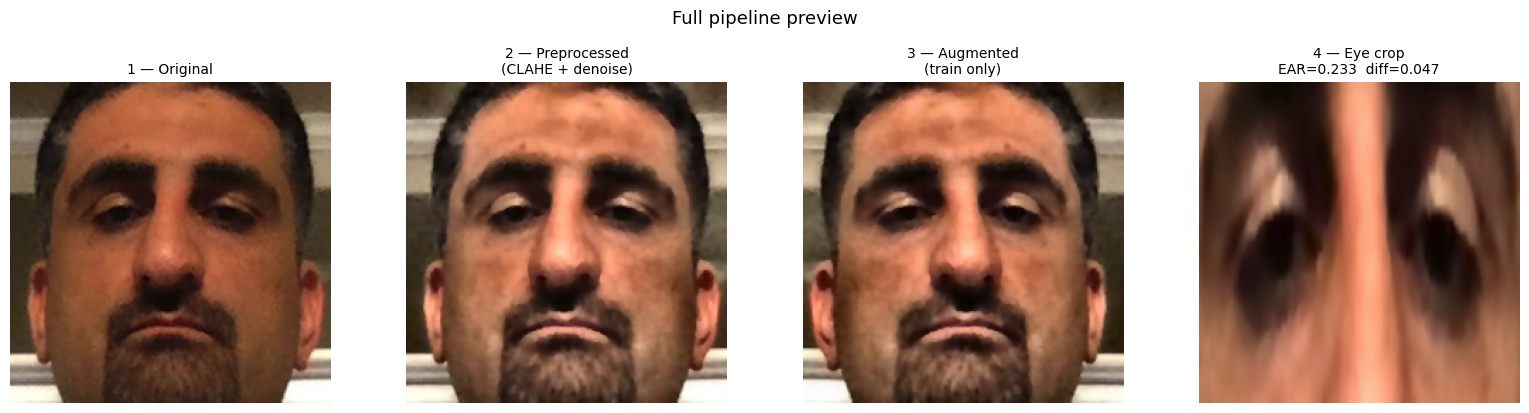

Saved → pipeline_preview.png


In [14]:
sample    = cv2.imread(train_df.iloc[0]["path"])
processed = preprocess_image(sample)
augmented = augment_image(processed) if processed is not None else None

with mp_face_mesh.FaceMesh(
    static_image_mode=True, max_num_faces=1,
    refine_landmarks=True, min_detection_confidence=0.5
) as fm:
    result = extract_eye_features(augmented, fm) if augmented is not None else None

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles  = ["1 — Original", "2 — Preprocessed\n(CLAHE + denoise)",
           "3 — Augmented\n(train only)", "4 — Eye crop"]
images  = [sample, processed, augmented,
           result[0] if result else None]

for ax, title, img in zip(axes, titles, images):
    if img is not None:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis("off")

if result:
    _, ear, ear_diff = result
    axes[3].set_title(f"4 — Eye crop\nEAR={ear:.3f}  diff={ear_diff:.3f}", fontsize=10)

plt.suptitle("Full pipeline preview", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pipeline_preview.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → pipeline_preview.png")